In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('../data/ratings.csv')

print(df.head(),"\n")
print(df.info(),"\n")
print(df.describe())

         Date               Name  Year        Letterboxd URI  Rating  \
0  2020-10-15           Whiplash  2014  https://boxd.it/7bQA     5.0   
1  2020-10-15         Your Name.  2016  https://boxd.it/cUqs     5.0   
2  2020-10-15    The Dark Knight  2008  https://boxd.it/2b0k     5.0   
3  2020-10-15      Black Panther  2018  https://boxd.it/8MHs     4.0   
4  2020-10-15  Avengers: Endgame  2019  https://boxd.it/9vE4     4.5   

                             Genres  Runtime  Average Rating  
0              Drama-Music-Thriller    107.0            4.42  
1           Animation-Romance-Drama    106.0            4.23  
2             Action-Crime-Thriller    152.0            4.49  
3  Action-Adventure-Science Fiction    135.0            3.70  
4  Adventure-Science Fiction-Action    181.0            3.96   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          -------------- 

In [3]:
df.isnull().sum()
df = df.dropna()

In [4]:
encoded_df = df['Genres'].str.get_dummies(sep='-')
df = df.join(encoded_df).drop(columns=['Genres'])
print(df.head())

         Date               Name  Year        Letterboxd URI  Rating  Runtime  \
0  2020-10-15           Whiplash  2014  https://boxd.it/7bQA     5.0    107.0   
1  2020-10-15         Your Name.  2016  https://boxd.it/cUqs     5.0    106.0   
2  2020-10-15    The Dark Knight  2008  https://boxd.it/2b0k     5.0    152.0   
3  2020-10-15      Black Panther  2018  https://boxd.it/8MHs     4.0    135.0   
4  2020-10-15  Avengers: Endgame  2019  https://boxd.it/9vE4     4.5    181.0   

   Average Rating  Action  Adventure  Animation  ...  History  Horror  Music  \
0            4.42       0          0          0  ...        0       0      1   
1            4.23       0          0          1  ...        0       0      0   
2            4.49       1          0          0  ...        0       0      0   
3            3.70       1          1          0  ...        0       0      0   
4            3.96       1          1          0  ...        0       0      0   

   Mystery  Romance  Science Fic

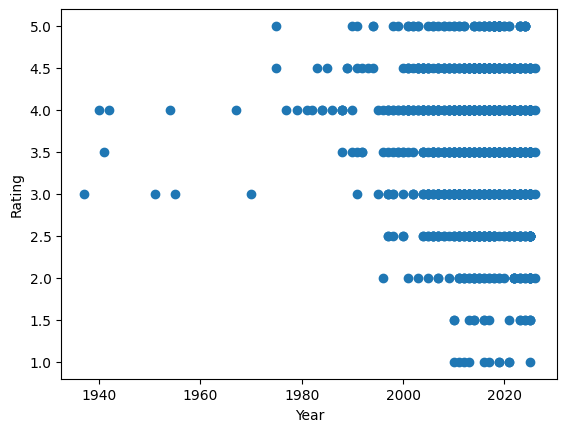

In [5]:
plt.scatter(df["Year"], df["Rating"])
plt.xlabel("Year")
plt.ylabel("Rating")
plt.show()

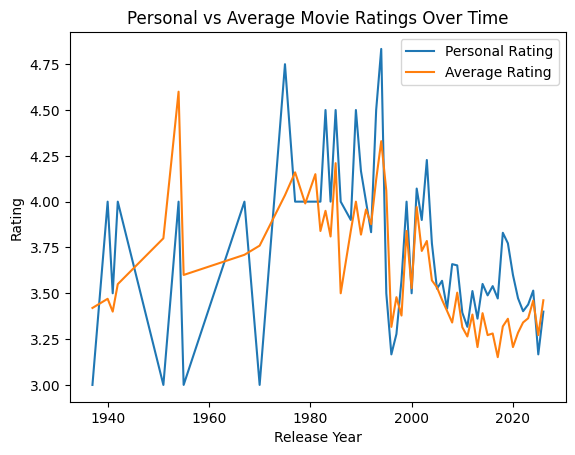

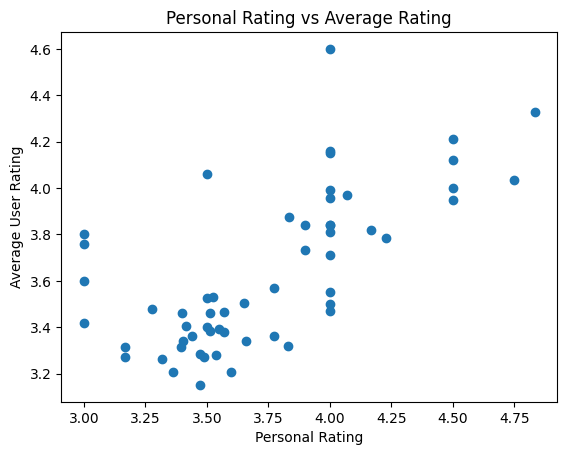

In [6]:
df_grouped = df.groupby('Year')[['Rating', 'Average Rating']].mean().reset_index()
df_grouped = df_grouped.sort_values(by='Year')

plt.figure()

plt.plot(df_grouped['Year'], df_grouped['Rating'], label='Personal Rating')
plt.plot(df_grouped['Year'], df_grouped['Average Rating'], label='Average Rating')

plt.xlabel('Release Year')
plt.ylabel('Rating')
plt.title('Personal vs Average Movie Ratings Over Time')
plt.legend()

plt.show()

plt.scatter(df_grouped["Rating"], df_grouped["Average Rating"])
plt.xlabel("Personal Rating")
plt.ylabel("Average User Rating")
plt.title("Personal Rating vs Average Rating")
plt.show()

Slope: 0.47544681330000077
Intercept: 1.841246515447325
MSE: 0.09933227845289516
R² Score: 0.38544335030839283


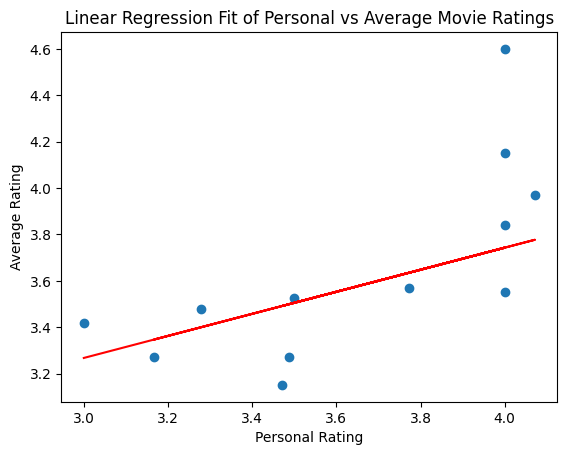

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X = df_grouped['Rating'].values.reshape(-1, 1)
y = df_grouped['Average Rating'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R² Score:", r2)

plt.scatter(X_test, y_test, label="Actual")
plt.plot(X_test, y_pred, color="red", label="Regression Line")
plt.xlabel('Personal Rating')
plt.ylabel('Average Rating')
plt.title('Linear Regression Fit of Personal vs Average Movie Ratings')
plt.show()

In [8]:
print(df_grouped.head())

   Year  Rating  Average Rating
0  1937     3.0            3.42
1  1940     4.0            3.47
2  1941     3.5            3.40
3  1942     4.0            3.55
4  1951     3.0            3.80


## Predicting User's Rating using only Genre and Runtime data

MAE: 0.7439925282831749
RMSE: 0.9035154030280967
R² Score: 0.019378861422872262


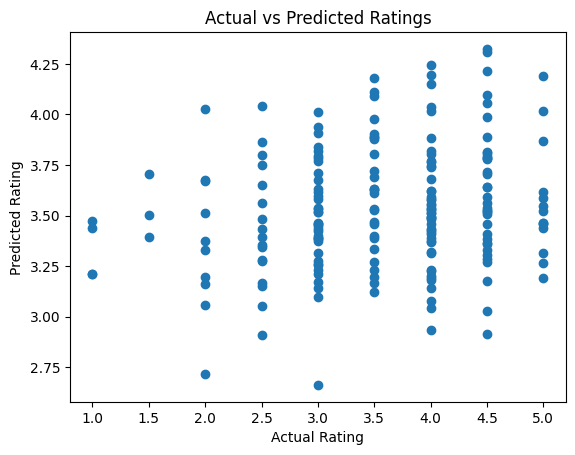

In [9]:
X = df.drop(columns=[
    'Date',
    'Name',
    'Letterboxd URI',
    'Average Rating',
    'Rating'   # target
])

y = df['Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings")
plt.show()

            Feature    Weight
7       Documentary  0.492911
13            Music  0.437263
14          Mystery  0.403099
4         Animation  0.298456
19              War  0.290701
6             Crime  0.258239
8             Drama  0.156834
11          History  0.086739
3         Adventure  0.052207
20          Western  0.037157
16  Science Fiction  0.029230
1           Runtime  0.002158
0              Year -0.011747
18         Thriller -0.053809
5            Comedy -0.145527
12           Horror -0.210511
10          Fantasy -0.213773
9            Family -0.240392
2            Action -0.350895
15          Romance -0.392193
17         TV Movie -0.866581


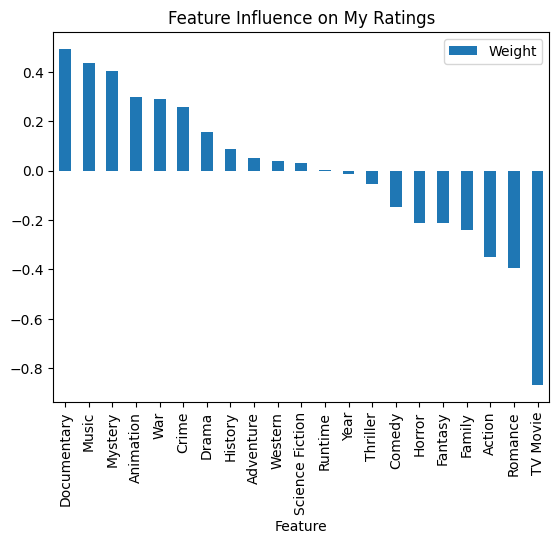

In [10]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Weight': model.coef_
}).sort_values(by='Weight', ascending=False)

print(coefficients)

coefficients.set_index('Feature').plot(kind='bar')
plt.title("Feature Influence on My Ratings")
plt.show()

In [11]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RF R²:", r2_score(y_test, y_pred_rf))

RF MAE: 0.7559595959595958
RF R²: -0.03911043088590138


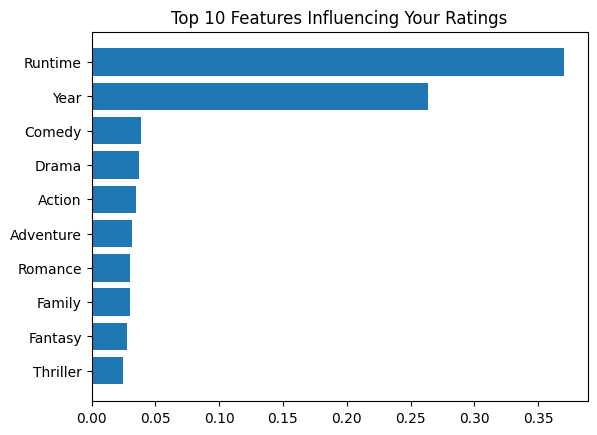

In [12]:
importances = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

top_features = feature_importance_df.head(10)

plt.figure()
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.title("Top 10 Features Influencing Your Ratings")
plt.show()

MAE: 0.7481462876149795
RMSE: 0.9099062452113114
R² Score: 0.005457329796697219


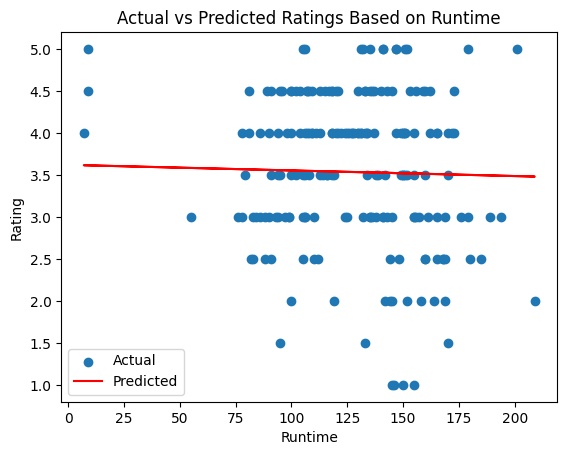

In [ ]:
X = df['Runtime']
y = df['Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train.values.reshape(-1, 1), y_train)

y_pred = model.predict(X_test.values.reshape(-1, 1))

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

plt.scatter(X_test, y_test, label="Actual")
plt.plot(X_test, y_pred, label="Predicted", color="red")
plt.xlabel("Runtime")
plt.ylabel("Rating")
plt.title("Actual vs Predicted Ratings Based on Runtime")
plt.legend()
plt.show()

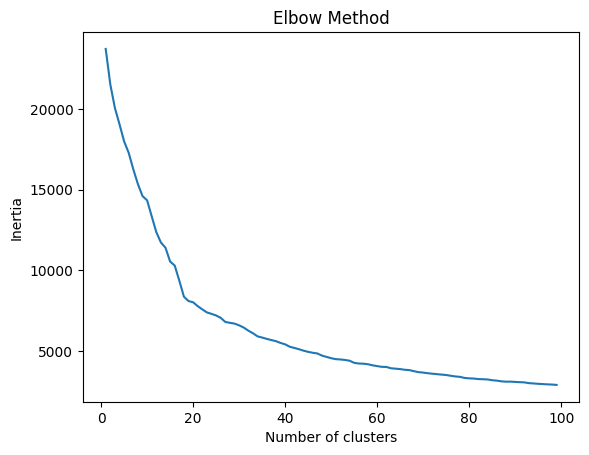

In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = df.drop(columns=[
    'Date',
    'Name',
    'Letterboxd URI'
])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []

for k in range(1, 100):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 100), inertia)
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

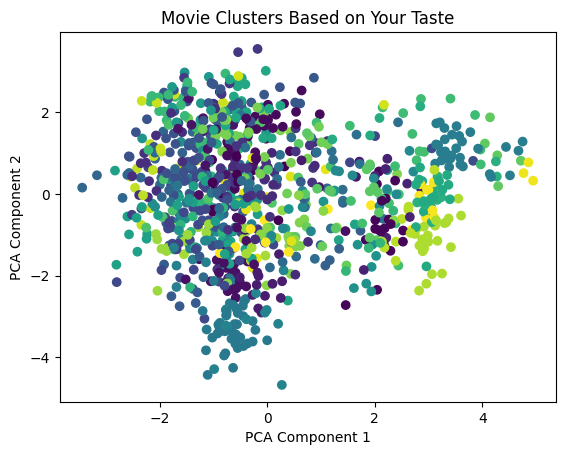

,Year,Rating,Runtime,Average Rating,Action,Adventure,Animation,Comedy,Crime,Documentary,...,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western,Cluster
Cluster,,,,,,,,,,,,,,,,,,,,,
0,2014.333333,2.833333,139.083333,2.985000,0.000000,0.000000,0.000000,0.416667,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.000,0.0,0.0,0.0
1,2012.555556,3.361111,95.388889,3.043333,0.055556,1.000000,0.000000,0.944444,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.000,0.0,0.0,1.0
2,2015.200000,4.266667,134.000000,3.736000,0.033333,0.100000,0.000000,1.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.066667,0.0,0.000,0.0,0.0,2.0
3,2016.243243,4.243243,140.459459,3.768919,0.837838,0.918919,0.027027,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,1.000000,0.0,0.000,0.0,0.0,3.0
4,2015.684211,4.000000,130.789474,3.772632,0.000000,0.157895,0.000000,0.315789,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,1.000,0.0,0.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,2021.333333,3.666667,100.333333,3.603333,0.333333,0.000000,0.000000,0.000000,0.0,0.0,...,1.0,0.0,0.0,0.0,0.000000,0.0,0.000,0.0,0.0,70.0
71,2008.250000,3.500000,100.750000,3.573750,0.000000,0.250000,0.125000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,1.000000,0.0,0.875,0.0,0.0,71.0
72,1942.666667,3.333333,82.000000,3.563333,0.000000,0.000000,1.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.000,0.0,0.0,72.0


In [42]:
from sklearn.decomposition import PCA

kmeans = KMeans(n_clusters=75, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'])
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Movie Clusters Based on Your Taste")
plt.show()

df.groupby('Cluster')[X.columns.tolist()].mean()

In [46]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

X = df.drop(columns=[
    'Date',
    'Name',
    'Letterboxd URI',
    'Average Rating',
    'Rating'   # target
])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

knn = NearestNeighbors(n_neighbors=6, metric='euclidean')
knn.fit(X_scaled)

def recommend_movies(movie_name, df, X_scaled, knn, n_recommendations=5):
    
    # Find index of the movie
    idx = df[df['Name'] == movie_name].index[0]
    
    # Get nearest neighbors
    distances, indices = knn.kneighbors([X_scaled[idx]])
    
    # Skip first one (itself)
    similar_indices = indices[0][1:]
    
    recommendations = df.iloc[similar_indices][['Name', 'Rating']]
    
    return recommendations

recommend_movies("Inception", df, X_scaled, knn)

liked_movies = df[df['Rating'] >= 4]

def recommend_from_liked(df, X_scaled, knn, n_recommendations=10):
    
    liked_indices = df[df['Rating'] >= 4].index
    
    recommendations = set()
    
    for idx in liked_indices:
        distances, indices = knn.kneighbors([X_scaled[idx]])
        for i in indices[0][1:]:
            recommendations.add(i)
    
    rec_df = df.iloc[list(recommendations)]
    
    # Remove already watched movies
    rec_df = rec_df[~rec_df.index.isin(liked_indices)]
    
    return rec_df[['Name', 'Average User Rating']].head(n_recommendations)

In [57]:
print("Recommended movies based on Movie A:'Spider-man: Into the Spider-Verse'")
print(recommend_movies("Spider-Man: Into the Spider-Verse", df, X_scaled, knn))
print()
print("Recommended movies based on Movie B:'Superman'")
print(recommend_movies("Dunkirk", df, X_scaled, knn))
print()
print("Recommended movies based on Movie C:'Annihilation'")
print(recommend_movies("Annihilation", df, X_scaled, knn))

Recommended movies based on Movie A:'Spider-man: Into the Spider-Verse'
                                    Name  Rating
98                         Incredibles 2     3.5
545    The Lego Movie 2: The Second Part     3.0
433                    Spies in Disguise     3.5
394                      Kung Fu Panda 3     3.5
698  Spider-Man: Across the Spider-Verse     4.5

Recommended movies based on Movie B:'Superman'
                             Name  Rating
156       Guardians of the Galaxy     4.5
168                    Iron Man 3     4.5
863                   Pacific Rim     4.0
179     Spider-Man: Far From Home     4.0
721  Star Wars: The Force Awakens     4.0

Recommended movies based on Movie C:'Annihilation'
                   Name  Rating
524                Nope     4.0
31          World War Z     3.5
740  Godzilla Minus One     4.0
86   Happy Death Day 2U     3.5
139       A Quiet Place     4.5
